# Motif Schur Decomposition Analysis

This notebook is the motif-level companion to the existing Schur decomposition workflow. It decomposes each exported 3x3 motif subnetwork, compares blocks with and without stored self-weights, and ranks motifs by local Schur-mode strength and non-normal triangular coupling.

## Configuration

The inputs are the Schur-ready 3x3 subnetwork exports produced by `motif_pathway_analysis.ipynb`. Those exports are source-to-target blocks: rows are presynaptic/source cell types and columns are postsynaptic/target cell types. This notebook transposes each 3x3 block once after loading, so all Schur/eigen analyses use the same convention as the global notebooks: rows are postsynaptic targets and columns are presynaptic sources.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import motif_schur_decomposition_analysis_script as analysis

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

INPUT_DIR=Path("outputs/motif_pathway_analysis")
OUTPUT_DIR=Path("outputs/motif_schur_decomposition_analysis"); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

NO_SELF_CSV=INPUT_DIR/"schur_ready_3x3_subnetworks_without_self.csv"
NO_SELF_NPZ=INPUT_DIR/"schur_ready_3x3_subnetworks_without_self.npz"
WITH_SELF_CSV=INPUT_DIR/"schur_ready_3x3_subnetworks_with_self.csv"
WITH_SELF_NPZ=INPUT_DIR/"schur_ready_3x3_subnetworks_with_self.npz"

MOTIF_INDEX_MATRIX_WEIGHT="spectral_radius"
MOTIF_INDEX_N_MODES=12
MOTIF_INDEX_NORMALIZE_ROWS=False

TRANSPOSE_SOURCE_TARGET_BLOCKS=True


MOTIF_ACTIVATION_GAIN=0.50



## Load motif subnetwork blocks

This section checks that the metadata rows and 3x3 arrays are aligned. The no-self block set supports motif-only Schur analysis, while the with-self block set shows how the diagonal terms alter the same local motif modes.

In [2]:
meta_no,blocks_no=analysis.load_schur_blocks(NO_SELF_CSV,NO_SELF_NPZ)
meta_self,blocks_self=analysis.load_schur_blocks(WITH_SELF_CSV,WITH_SELF_NPZ)
if TRANSPOSE_SOURCE_TARGET_BLOCKS:
    blocks_no=blocks_no.transpose(0,2,1)
    blocks_self=blocks_self.transpose(0,2,1)
BLOCK_ORIENTATION="rows=postsynaptic target, columns=presynaptic source"
all_cell_types=pd.concat([meta_no[["node_1","node_2","node_3"]].stack(),meta_self[["node_1","node_2","node_3"]].stack()],ignore_index=True)
acronym_map=analysis.make_acronym_map(all_cell_types)
acronyms=analysis.acronym_table(acronym_map)
print("without self metadata/block shape:",meta_no.shape,blocks_no.shape)
print("with self metadata/block shape:",meta_self.shape,blocks_self.shape)
print("block orientation used for analysis:",BLOCK_ORIENTATION)
print("cell-type acronyms:",len(acronyms))
display(acronyms.head(25))
display(analysis.add_acronym_columns(meta_no.head(10),acronym_map))


without self metadata/block shape: (39141, 19) (39141, 3, 3)
with self metadata/block shape: (39141, 19) (39141, 3, 3)
cell-type acronyms: 85


,cell_type,cell_type_acronym
0,CA1 Axo Axonic,CA1-AxAxo
1,CA1 Back Projection,CA1-BackProj
2,CA1 Basket,CA1-Bas
3,CA1 Basket CCK+,CA1-BasCCK
4,CA1 Bistratified,CA1-Bi
5,CA1 Horizontal Axo Axonic,CA1-HorAxAxo
6,CA1 Horizontal Basket,CA1-HorBas
7,CA1 Ivy,CA1-Ivy
8,CA1 LMR,CA1-LMR
9,CA1 Neurogliaform,CA1-NGF


,motif_index,nodes,node_1,node_2,node_3,superpattern,superpattern_letter,canonical_motif_id,observed_motif_code,include_self_weights,w_11,w_12,w_13,w_21,w_22,w_23,w_31,w_32,w_33,node_1_acronym,node_2_acronym,node_3_acronym,motif_acronym
0,0,DG Granule | DG AIPRIM | DG HICAP,DG Granule,DG AIPRIM,DG HICAP,M,M,111111,111111,False,0.0,14.357657,5.752152,-0.014855,0.0,-0.134166,-0.000360,-0.001132,0.0,DG-Gr,DG-AIPRIM,DG-HICAP,DG-Gr | DG-AIPRIM | DG-HICAP
1,1,DG Granule | DG AIPRIM | DG MOLAX,DG Granule,DG AIPRIM,DG MOLAX,M,M,111111,111111,False,0.0,14.357657,2.987560,-0.014855,0.0,-0.057940,-0.009858,-0.030409,0.0,DG-Gr,DG-AIPRIM,DG-MOLAX,DG-Gr | DG-AIPRIM | DG-MOLAX
2,2,DG Granule | DG AIPRIM | DG Total Molecular Layer,DG Granule,DG AIPRIM,DG Total Molecular Layer,M,M,111111,111111,False,0.0,14.357657,2.862911,-0.014855,0.0,-0.043096,-0.011683,-0.074719,0.0,DG-Gr,DG-AIPRIM,DG-TotMolLay,DG-Gr | DG-AIPRIM | DG-TotMolLay
3,3,DG Granule | DG AIPRIM | DG HIPROM,DG Granule,DG AIPRIM,DG HIPROM,M,M,111111,111111,False,0.0,14.357657,2.061017,-0.014855,0.0,-0.043796,-0.000021,-0.000263,0.0,DG-Gr,DG-AIPRIM,DG-HIPROM,DG-Gr | DG-AIPRIM | DG-HIPROM
4,4,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Superficial Multipolar Interneuron,EC LI II Multipolar Pyramidal,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,M,M,111111,111111,False,0.0,1.847420,26.131776,0.269956,0.0,2.237797,-0.002694,-0.003571,0.0,EC-LI/II-MP,EC-LII/III-PT,MEC-LIII-SupMIN,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN
5,5,DG Granule | DG AIPRIM | DG HIPP,DG Granule,DG AIPRIM,DG HIPP,M,M,111111,111111,False,0.0,14.357657,0.906403,-0.014855,0.0,-0.003893,-0.012916,-0.035940,0.0,DG-Gr,DG-AIPRIM,DG-HIP,DG-Gr | DG-AIPRIM | DG-HIP
6,6,DG Granule | DG AIPRIM | DG Axo Axonic,DG Granule,DG AIPRIM,DG Axo Axonic,L,L,11111,111110,False,0.0,14.357657,12.279554,-0.014855,0.0,-0.133895,-0.000830,0.000000,0.0,DG-Gr,DG-AIPRIM,DG-AxAxo,DG-Gr | DG-AIPRIM | DG-AxAxo
7,7,CA3 Pyramidal | CA1 Back Projection | CA1 Trilaminar,CA3 Pyramidal,CA1 Back Projection,CA1 Trilaminar,L,L,11111,111011,False,0.0,10.467823,78.584936,-0.007522,0.0,-0.035719,0.000000,-0.008362,0.0,CA3-P,CA1-BackProj,CA1-TriLam,CA3-P | CA1-BackProj | CA1-TriLam
8,8,DG Granule | DG AIPRIM | DG Basket,DG Granule,DG AIPRIM,DG Basket,L,L,11111,111110,False,0.0,14.357657,2.230612,-0.014855,0.0,-0.052178,-0.015195,0.000000,0.0,DG-Gr,DG-AIPRIM,DG-Bas,DG-Gr | DG-AIPRIM | DG-Bas
9,9,EC LI II Multipolar Pyramidal | MEC LIII Superficial Multipolar Interneuron | MEC LIII Superficial Trilayered Interneuron,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Trilayered Interneuron,M,M,111111,111111,False,0.0,26.131776,1.785591,-0.002694,0.0,-0.009885,-0.008282,-0.163493,0.0,EC-LI/II-MP,MEC-LIII-SupMIN,MEC-LIII-SupTriIN,EC-LI/II-MP | MEC-LIII-SupMIN | MEC-LIII-SupTriIN


## Schur decomposition of every 3x3 motif

For each motif block, the complex Schur decomposition writes the local matrix as a unitary basis times an upper-triangular interaction matrix. The eigenvalues on the diagonal describe local modal strength; the off-diagonal triangular entries capture non-normal feed-through between Schur modes.

In [3]:
schur_no=analysis.decompose_blocks(meta_no,blocks_no,"without_self",acronym_map=acronym_map)
schur_self=analysis.decompose_blocks(meta_self,blocks_self,"with_self",acronym_map=acronym_map)
print("decomposed motifs:",len(schur_no),len(schur_self))
display(schur_no.head(15)[["motif_acronym","superpattern","spectral_radius","schur_offdiag_norm","schur_departure_ratio","dominant_schur_node_acronym","dominant_schur_participation","schur_eigenvalues"]])


decomposed motifs: 39141 39141


,motif_acronym,superpattern,spectral_radius,schur_offdiag_norm,schur_departure_ratio,dominant_schur_node_acronym,dominant_schur_participation,schur_eigenvalues
17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,0.827766,2.161518,0.888121,EC-LI/II-MP,0.878797,"0.8278+0j, -0.7482+0j, -0.07961+0j"
78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,0.786794,1.610918,0.830380,EC-LI/II-MP,0.631891,"0.7868+0j, -0.7397+0j, -0.04707+0j"
29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,M,0.740979,1.799544,0.867633,EC-LI/II-MP,0.874181,"0.741+0j, -0.7168+0j, -0.02415+0j"
27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,M,0.728986,1.914546,0.882949,EC-LI/II-MP,0.876045,"0.729+0j, -0.7103+0j, -0.0187+0j"
39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,M,0.726138,1.668695,0.853385,EC-LI/II-MP,0.874184,"0.7261+0j, -0.7153+0j, -0.01088+0j"
19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,M,0.719044,2.516064,0.927654,EC-LI/II-MP,0.875542,"0.719+0j, -0.7134+0j, -0.005694+0j"
20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,M,0.717057,2.088080,0.900455,EC-LI/II-MP,0.874431,"0.7171+0j, -0.7093+0j, -0.007782+0j"
67,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-PSt,L,0.712607,1.979797,0.892518,EC-LI/II-MP,0.873696,"0.7126+0j, -0.7021+0j, -0.01049+0j"
44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,M,0.710753,1.582473,0.844696,EC-LI/II-MP,0.871736,"0.7108+0j, -0.7073+0j, -0.003424+0j"
81,EC-LI/II-MP | EC-LII/III-PT | EC-LIII/V-BipP,L,0.709209,1.628998,0.852324,EC-LI/II-MP,0.872951,"0.7092+0j, -0.7044+0j, -0.004783+0j"


## Eigenspectrum of motif Schur decompositions

The eigenspectrum plot shows all three Schur/eigen modes for every enumerated motif. Points farther from the origin correspond to stronger local modes; separation between no-self and with-self panels shows how restored diagonal weights move the local spectra.


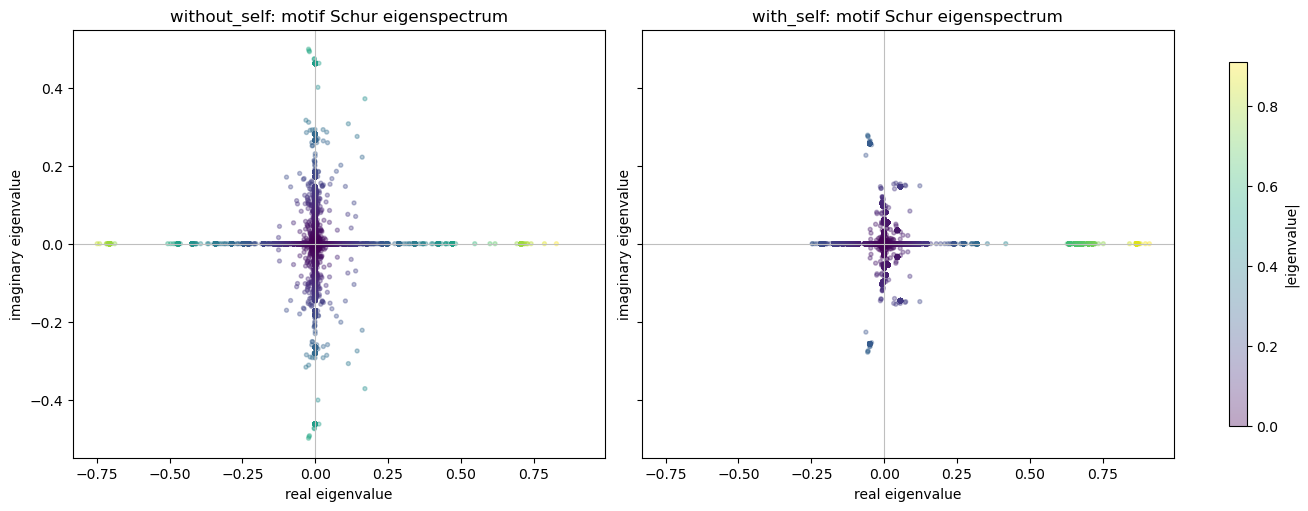

,scenario,motif_acronym,superpattern,eigenvalue_real,eigenvalue_imag,eigenvalue_abs
117423,with_self,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,0.9102,0.0,0.9102
117426,with_self,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,0.8965,0.0,0.8965
117429,with_self,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,M,0.8795,0.0,0.8795
117432,with_self,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,M,0.8743,0.0,0.8743
117435,with_self,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,M,0.8740,0.0,0.8740
117438,with_self,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,M,0.8716,0.0,0.8716
117441,with_self,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,M,0.8704,0.0,0.8704
117444,with_self,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,M,0.8684,0.0,0.8684
117447,with_self,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-PSt,L,0.8681,0.0,0.8681
117450,with_self,EC-LI/II-MP | EC-LII/III-PT | EC-LIII/V-BipP,L,0.8674,0.0,0.8674


In [4]:
spectrum=pd.concat([analysis.eigenspectrum_points(schur_no),analysis.eigenspectrum_points(schur_self)],ignore_index=True)
fig,axes=plt.subplots(1,2,figsize=(13,5),sharex=True,sharey=True,constrained_layout=True)
for scenario,ax in zip(["without_self","with_self"],axes):
    plot=spectrum[spectrum.scenario==scenario]
    scatter=ax.scatter(plot.eigenvalue_real,plot.eigenvalue_imag,c=plot.eigenvalue_abs,s=8,alpha=0.35,cmap="viridis")
    ax.axhline(0,color="0.75",linewidth=0.8); ax.axvline(0,color="0.75",linewidth=0.8)
    ax.set(title=f"{scenario}: motif Schur eigenspectrum",xlabel="real eigenvalue",ylabel="imaginary eigenvalue")
fig.colorbar(scatter,ax=axes,label="|eigenvalue|",shrink=0.85)
plt.show()
display(spectrum.nlargest(15,"eigenvalue_abs")[["scenario","motif_acronym","superpattern","eigenvalue_real","eigenvalue_imag","eigenvalue_abs"]])



## Ranked Schur modes across all motifs

This section expands every motif into its three Schur modes and ranks those individual modes globally. Unlike the motif-level table above, this printout asks which specific Schur modes are strongest, even when they are not the first row shown for a representative motif.


Top ranked Schur modes without self-weights


,global_schur_mode_rank,motif_index,motif_acronym,superpattern,schur_mode,eigenvalue_real,eigenvalue_imag,eigenvalue_abs,dominant_node_acronym,dominant_node_participation,schur_upper_coupling_out_abs
0,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,1,0.827766,0.0,0.827766,EC-LI/II-MP,0.878797,2.907756
1,2,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,1,0.786794,0.0,0.786794,EC-LI/II-MP,0.631891,1.787137
2,3,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,2,-0.748156,0.0,0.748156,EC-LII/III-PT,0.819470,0.176443
3,4,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,M,1,0.740979,0.0,0.740979,EC-LI/II-MP,0.874181,2.329104
4,5,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,2,-0.739727,0.0,0.739727,EC-LI/II-PFan,0.472857,0.840505
5,6,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,M,1,0.728986,0.0,0.728986,EC-LI/II-MP,0.876045,2.595059
6,7,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,M,1,0.726138,0.0,0.726138,EC-LI/II-MP,0.874184,1.963876
7,8,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,M,1,0.719044,0.0,0.719044,EC-LI/II-MP,0.875542,3.451824
8,9,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,M,1,0.717057,0.0,0.717057,EC-LI/II-MP,0.874431,2.892575
9,10,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,M,2,-0.716825,0.0,0.716825,EC-LII/III-PT,0.859852,0.082235


Top ranked Schur modes with self-weights


,global_schur_mode_rank,motif_index,motif_acronym,superpattern,schur_mode,eigenvalue_real,eigenvalue_imag,eigenvalue_abs,dominant_node_acronym,dominant_node_participation,schur_upper_coupling_out_abs
0,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,1,0.910179,0.0,0.910179,EC-LI/II-MP,0.961839,1.636551
1,2,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,1,0.896489,0.0,0.896489,EC-LI/II-MP,0.875662,1.051297
2,3,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,M,1,0.879460,0.0,0.879460,EC-LI/II-MP,0.962894,1.321111
3,4,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,M,1,0.874254,0.0,0.874254,EC-LI/II-MP,0.963589,1.502079
4,5,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,M,1,0.874033,0.0,0.874033,EC-LI/II-MP,0.963209,1.126121
5,6,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,M,1,0.871566,0.0,0.871566,EC-LI/II-MP,0.963712,1.995717
6,7,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,M,1,0.870425,0.0,0.870425,EC-LI/II-MP,0.963552,1.661832
7,8,44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,M,1,0.868350,0.0,0.868350,EC-LI/II-MP,0.963124,0.915112
8,9,67,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-PSt,L,1,0.868080,0.0,0.868080,EC-LI/II-MP,0.963478,1.575458
9,10,81,EC-LI/II-MP | EC-LII/III-PT | EC-LIII/V-BipP,L,1,0.867405,0.0,0.867405,EC-LI/II-MP,0.963442,1.164838


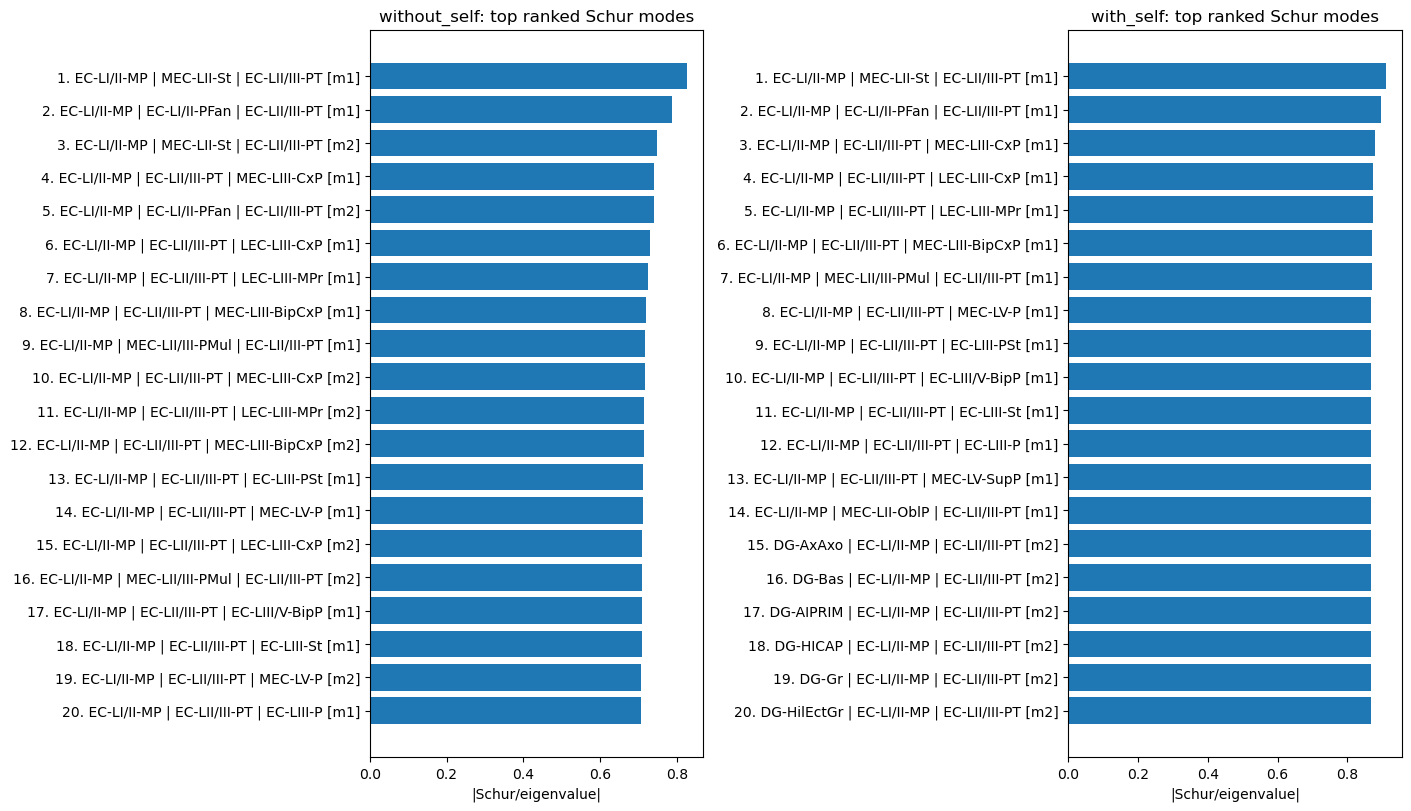

In [5]:
ranked_modes_no=analysis.rank_all_schur_modes(meta_no,blocks_no,"without_self",acronym_map=acronym_map)
ranked_modes_self=analysis.rank_all_schur_modes(meta_self,blocks_self,"with_self",acronym_map=acronym_map)
ranked_mode_columns=["global_schur_mode_rank","motif_index","motif_acronym","superpattern","schur_mode","eigenvalue_real","eigenvalue_imag","eigenvalue_abs","dominant_node_acronym","dominant_node_participation","schur_upper_coupling_out_abs"]
print("Top ranked Schur modes without self-weights")
display(ranked_modes_no.head(30)[ranked_mode_columns])
print("Top ranked Schur modes with self-weights")
display(ranked_modes_self.head(30)[ranked_mode_columns])
fig,axes=plt.subplots(1,2,figsize=(14,8),constrained_layout=True)
for title,frame,ax in [("without_self",ranked_modes_no,axes[0]),("with_self",ranked_modes_self,axes[1])]:
    plot=frame.head(20).iloc[::-1]
    labels=plot["global_schur_mode_rank"].astype(str)+". "+plot["motif_acronym"]+" [m"+plot["schur_mode"].astype(str)+"]"
    ax.barh(labels,plot["eigenvalue_abs"])
    ax.set(title=f"{title}: top ranked Schur modes",xlabel="|Schur/eigenvalue|",ylabel="")
plt.show()


## Motif enhancement and ablation testing

This section perturbs each enumerated motif locally. Enhancement multiplies the off-diagonal motif edges by `1 + MOTIF_ACTIVATION_GAIN` while preserving sign, so inhibitory edges become stronger inhibition. Ablation removes the off-diagonal motif edges. In the with-self scenario, diagonal self-weights remain present during ablation; in the no-self scenario, ablation leaves a zero 3x3 block.


Most activation-sensitive motifs without self-weights


,motif_index,motif_acronym,superpattern,baseline_spectral_radius,enhanced_spectral_radius,ablated_spectral_radius,enhancement_delta_spectral_radius,ablation_delta_spectral_radius,baseline_resolvent_gain_z1,enhanced_resolvent_gain_z1,ablated_resolvent_gain_z1,activation_sensitivity_score,removal_sensitivity_score
0,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,M,0.687854,1.031781,0.0,0.343927,-0.687854,51.532141,295.467130,1.0,244.278916,51.219994
1,45,CA3c-P | CA2-P | CA1-PerPatAss.2,K,0.470635,0.705952,0.0,0.235317,-0.470635,88.959215,220.573821,1.0,131.849923,88.429850
2,59,CA3c-P | CA2-P | CA1-PerPatAss,K,0.470635,0.705952,0.0,0.235317,-0.470635,72.595705,179.823947,1.0,107.463559,72.066340
3,73,CA3c-P | CA2-P | CA1-RRecApi,K,0.470635,0.705952,0.0,0.235317,-0.470635,53.625379,136.707585,1.0,83.317523,53.096014
4,167,CA3-P | CA2-P | CA1-TriLam,K,0.246451,0.369676,0.0,0.123225,-0.246451,89.478006,150.773903,1.0,61.419123,88.724457
5,309,DG-AxAxo | EC-LI/II-MP | EC-LII/III-PT,F,0.706203,1.059305,0.0,0.353102,-0.706203,8.563175,66.808142,1.0,58.598068,8.269378
6,22,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupTriIN,M,0.698779,1.048168,0.0,0.349389,-0.698779,6.154611,61.666005,1.0,55.860783,5.853390
7,99,CA3c-P | CA2-P | CA1-ORLM,K,0.470635,0.705952,0.0,0.235317,-0.470635,34.349861,85.696142,1.0,51.581598,33.820496
8,395,CA3-P | CA3c-P | CA1-PerPatAss.2,K,0.103048,0.154572,0.0,0.051524,-0.103048,73.059466,123.302168,1.0,50.294226,72.162515
9,121,CA3c-P | CA2-P | CA1-TriLam,K,0.470635,0.705952,0.0,0.235317,-0.470635,27.081946,76.400478,1.0,49.553850,26.552581


Most activation-sensitive motifs with self-weights


,motif_index,motif_acronym,superpattern,baseline_spectral_radius,enhanced_spectral_radius,ablated_spectral_radius,enhancement_delta_spectral_radius,ablation_delta_spectral_radius,baseline_resolvent_gain_z1,enhanced_resolvent_gain_z1,ablated_resolvent_gain_z1,activation_sensitivity_score,removal_sensitivity_score
0,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,M,0.842018,0.991921,0.663075,0.149904,-0.178942,75.062589,2053.318328,2.968021,1978.405643,72.273511
1,22,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupTriIN,M,0.861770,1.030102,0.663075,0.168331,-0.198695,11.474581,64.285592,2.968021,52.979343,8.705256
2,309,DG-AxAxo | EC-LI/II-MP | EC-LII/III-PT,F,0.866821,1.038985,0.663075,0.172164,-0.203746,11.960665,59.027546,2.968021,47.239044,9.196390
3,50,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-St,L,0.867362,1.040143,0.663075,0.172781,-0.204287,12.173937,49.249661,2.968021,37.248504,9.410204
4,63,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-P,L,0.866935,1.039229,0.663075,0.172293,-0.203860,11.283900,45.715879,2.968021,34.604272,8.519740
5,69,EC-LI/II-MP | MEC-LII-OblP | EC-LII/III-PT,L,0.866873,1.039096,0.663075,0.172224,-0.203798,10.461757,41.648374,2.968021,31.358841,7.697533
6,45,CA3c-P | CA2-P | CA1-PerPatAss.2,K,0.318620,0.451347,0.078395,0.132727,-0.240225,41.475806,72.466632,1.085064,31.123553,40.630967
7,167,CA3-P | CA2-P | CA1-TriLam,K,0.239565,0.308833,0.118816,0.069269,-0.120749,53.421330,84.293859,1.134836,30.941797,52.407243
8,67,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-PSt,L,0.868080,1.041667,0.663075,0.173587,-0.205005,10.818728,40.306846,2.968021,29.661704,8.055712
9,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,M,0.871566,1.047276,0.663075,0.175710,-0.208491,12.499810,41.055777,2.968021,28.731677,9.740280


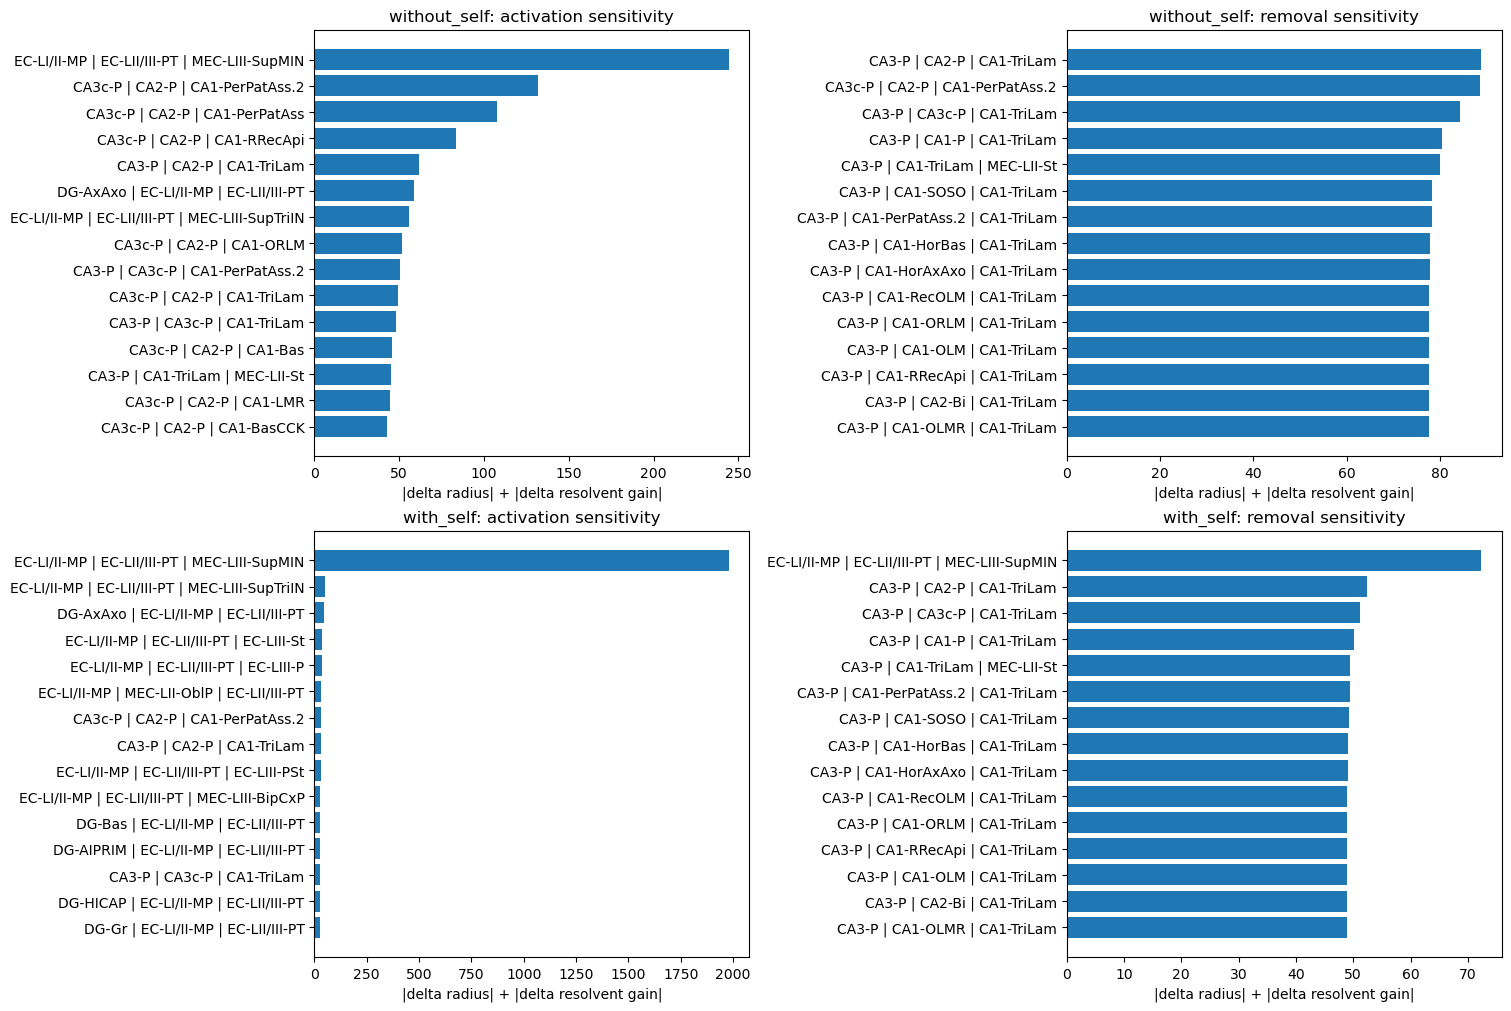

In [6]:
perturb_no=analysis.enhancement_ablation_test(meta_no,blocks_no,"without_self",activation_gain=MOTIF_ACTIVATION_GAIN,acronym_map=acronym_map)
perturb_self=analysis.enhancement_ablation_test(meta_self,blocks_self,"with_self",activation_gain=MOTIF_ACTIVATION_GAIN,acronym_map=acronym_map)
perturb_columns=["motif_index","motif_acronym","superpattern","baseline_spectral_radius","enhanced_spectral_radius","ablated_spectral_radius","enhancement_delta_spectral_radius","ablation_delta_spectral_radius","baseline_resolvent_gain_z1","enhanced_resolvent_gain_z1","ablated_resolvent_gain_z1","activation_sensitivity_score","removal_sensitivity_score"]
print("Most activation-sensitive motifs without self-weights")
display(perturb_no.head(25)[perturb_columns])
print("Most activation-sensitive motifs with self-weights")
display(perturb_self.head(25)[perturb_columns])
fig,axes=plt.subplots(2,2,figsize=(15,10),constrained_layout=True)
for frame,title,row in [(perturb_no,"without_self",0),(perturb_self,"with_self",1)]:
    activation_plot=frame.nlargest(15,"activation_sensitivity_score").iloc[::-1]
    axes[row,0].barh(activation_plot["motif_acronym"],activation_plot["activation_sensitivity_score"])
    axes[row,0].set(title=f"{title}: activation sensitivity",xlabel="|delta radius| + |delta resolvent gain|")
    removal_plot=frame.nlargest(15,"removal_sensitivity_score").iloc[::-1]
    axes[row,1].barh(removal_plot["motif_acronym"],removal_plot["removal_sensitivity_score"])
    axes[row,1].set(title=f"{title}: removal sensitivity",xlabel="|delta radius| + |delta resolvent gain|")
plt.show()


## Enumerated Schur modes for representative motifs

This printout expands the top-ranked motif into its three Schur modes. Each row lists one mode, its eigenvalue, the dominant cell-type acronym, participation across the three cells, and the amount of upper-triangular coupling from that mode into later Schur modes.


In [7]:
TOP_MOTIF_INDEX=int(schur_no.iloc[0].motif_index)
mode_source,block_preview,mode_table,triangular_T=analysis.enumerate_schur_modes(meta_no,blocks_no,TOP_MOTIF_INDEX,acronym_map=acronym_map)
print("Representative motif index:",TOP_MOTIF_INDEX)
print("Full motif:",mode_source.nodes)
print("Abbreviated motif:"," | ".join([acronym_map[mode_source.node_1],acronym_map[mode_source.node_2],acronym_map[mode_source.node_3]]))
print("Superpattern letter:",mode_source.superpattern_letter)
print("3x3 no-self block used for Schur decomposition")
display(block_preview)
print("Enumerated Schur modes")
display(mode_table)
print("Complex Schur triangular matrix T")
display(triangular_T)


Representative motif index: 17
Full motif: EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar
Abbreviated motif: EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT
Superpattern letter: M
3x3 no-self block used for Schur decomposition


,EC-LI/II-MP,MEC-LII-St,EC-LII/III-PT
EC-LI/II-MP,0.000000,1.545222,1.84742
MEC-LII-St,0.075542,0.000000,0.04988
EC-LII/III-PT,0.269956,0.204180,0.00000


Enumerated Schur modes


,mode,eigenvalue_real,eigenvalue_imag,eigenvalue_abs,dominant_node,dominant_node_acronym,EC-LI/II-MP_participation,MEC-LII-St_participation,EC-LII/III-PT_participation,upper_triangular_coupling_out_abs
0,1,0.827766,0.0,0.827766,EC LI II Multipolar Pyramidal,EC-LI/II-MP,0.878797,0.011139,0.110063,2.907756
1,2,-0.748156,0.0,0.748156,EC LII III Pyramidal Tripolar,EC-LII/III-PT,0.120990,0.059541,0.819470,0.176443
2,3,-0.079609,0.0,0.079609,MEC LII Stellate,MEC-LII-St,0.000213,0.929320,0.070467,0.000000


Complex Schur triangular matrix T


,mode_1,mode_2,mode_3
mode_1,0.827766+0.000000j,1.908579+0.000000j,0.999176+0.000000j
mode_2,0.000000+0.000000j,-0.748156+0.000000j,-0.176443+0.000000j
mode_3,0.000000+0.000000j,0.000000+0.000000j,-0.079609+0.000000j


## Motif-index matrix decomposition

This section treats each enumerated 3-node motif as a single indexed unit. The matrix rows are `motif_index` values and the columns are cell types; a motif places its Schur strength into the three columns for the cell types it contains. Decomposing this motif-index matrix asks which groups of motif occurrences co-vary through shared cell-type composition and Schur strength.


In [8]:
motif_index_no=analysis.decompose_motif_index_matrix(
    schur_no,
    acronym_map=acronym_map,
    weight_column=MOTIF_INDEX_MATRIX_WEIGHT,
    normalize_rows=MOTIF_INDEX_NORMALIZE_ROWS,
    n_modes=MOTIF_INDEX_N_MODES,
)
motif_index_self=analysis.decompose_motif_index_matrix(
    schur_self,
    acronym_map=acronym_map,
    weight_column=MOTIF_INDEX_MATRIX_WEIGHT,
    normalize_rows=MOTIF_INDEX_NORMALIZE_ROWS,
    n_modes=MOTIF_INDEX_N_MODES,
)
print("without-self motif-index matrix:",motif_index_no["matrix"].shape)
print("with-self motif-index matrix:",motif_index_self["matrix"].shape)
display(motif_index_no["matrix"].iloc[:8,:12])
display(motif_index_no["modes"])


without-self motif-index matrix: (39141, 85)
with-self motif-index matrix: (39141, 85)


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy,CA1 LMR,CA1 Neurogliaform,CA1 Neurogliaform Projecting,CA1 O LM
motif_index,,,,,,,,,,,,
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mode,singular_value,explained_energy_fraction,top_motif_index,top_motif_acronym,top_superpattern,top_cell_type,top_cell_acronym,top_motif_score,top_cell_loading
0,1,10.362229,0.200608,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-1.217842,-0.802346
1,2,7.954356,0.118209,351,DG-Gr | CA3c-P | CA2-P,L,DG Granule,DG-Gr,-0.648302,-0.827911
2,3,6.763001,0.085452,159,CA3-P | CA3c-P | CA2-P,M,CA3c Pyramidal,CA3c-P,0.928910,0.668458
3,4,4.718382,0.041594,330,EC-LI/II-MP | EC-LI/II-PFan | MEC-LII-St,M,EC LII III Pyramidal Tripolar,EC-LII/III-PT,0.427876,-0.548385
4,5,4.643539,0.040285,1137,CA3-P | EC-LI/II-MP | EC-LII/III-PT,-A,CA3 Pyramidal,CA3-P,-0.612920,-0.722172
5,6,4.245409,0.033673,475,DG-AIPRIM | EC-LI/II-MP | EC-LII/III-PT,F,DG AIPRIM,DG-AIPRIM,-0.502163,-0.710596
6,7,3.575195,0.023880,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,MEC LII Stellate,MEC-LII-St,0.668934,0.750663
7,8,3.417406,0.021819,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,M,MEC LIII Superficial Multipolar Interneuron,MEC-LIII-SupMIN,0.580334,0.827146
8,9,3.167133,0.018740,1118,CA2-P | EC-LI/II-MP | EC-LII/III-PT,-A,CA2 Pyramidal,CA2-P,0.368604,0.517496
9,10,2.863397,0.015318,1120,DG-Mossy | EC-LI/II-MP | EC-LII/III-PT,-A,DG Mossy,DG-Mossy,0.298481,0.425523


## Motif-index singular spectrum and mode printout

The singular values summarize how many independent motif-index patterns are needed to explain the matrix. The mode printout lists the motif indices and cell types that contribute most strongly to the leading latent motif-index modes.


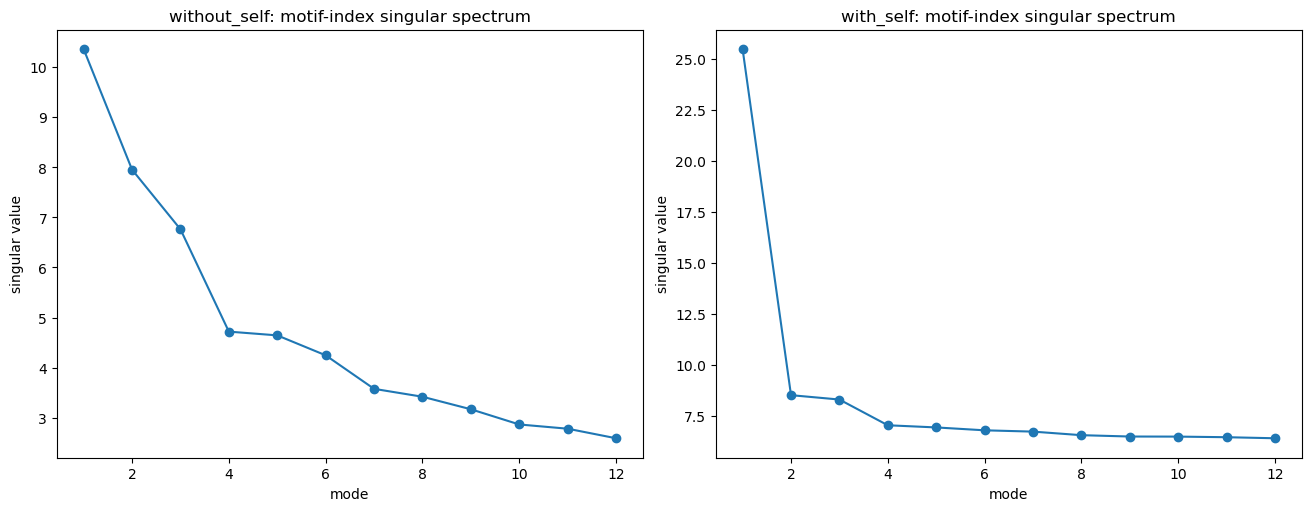

Top motif-index contributors, without self-weights


,mode,rank,motif_index,motif_acronym,nodes,superpattern,motif_score,abs_motif_score,spectral_radius
0,1,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar,M,-1.217842,1.217842,0.827766
1,1,2,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,EC LI II Multipolar Pyramidal | EC LI II Pyramidal Fan | EC LII III Pyramidal Tripolar,M,-1.127194,1.127194,0.786794
2,1,3,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Complex Pyramidal,M,-1.037906,1.037906,0.740979
3,1,4,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Complex Pyramidal,M,-1.010292,1.010292,0.728986
4,1,5,479,DG-Gr | EC-LI/II-MP | EC-LII/III-PT,DG Granule | EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar,F,-1.007879,1.007879,0.706203
5,1,6,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Multipolar Principal,M,-1.007217,1.007217,0.726138
6,1,7,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Bipolar Complex Pyramidal,M,-0.994958,0.994958,0.719044
7,1,8,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII III Pyramidal Multiform | EC LII III Pyramidal Tripolar,M,-0.990367,0.990367,0.717057
8,1,9,1111,CA3c-P | EC-LI/II-MP | EC-LII/III-PT,CA3c Pyramidal | EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar,-A,-0.988004,0.988004,0.706203
9,1,10,475,DG-AIPRIM | EC-LI/II-MP | EC-LII/III-PT,DG AIPRIM | EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar,F,-0.985978,0.985978,0.706203


Top cell loadings, without self-weights


,mode,rank,cell_type,cell_type_acronym,cell_loading,abs_cell_loading
0,1,1,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-0.802346,0.802346
1,1,2,EC LII III Pyramidal Tripolar,EC-LII/III-PT,-0.560379,0.560379
2,1,3,MEC LII Stellate,MEC-LII-St,-0.108516,0.108516
3,1,4,EC LI II Pyramidal Fan,EC-LI/II-PFan,-0.069918,0.069918
4,1,5,MEC LIII Superficial Multipolar Interneuron,MEC-LIII-SupMIN,-0.065012,0.065012
5,1,6,DG Granule,DG-Gr,-0.064455,0.064455
6,1,7,MEC LIII Complex Pyramidal,MEC-LIII-CxP,-0.037998,0.037998
7,1,8,CA3c Pyramidal,CA3c-P,-0.036312,0.036312
8,1,9,DG AIPRIM,DG-AIPRIM,-0.033444,0.033444
9,1,10,CA2 Pyramidal,CA2-P,-0.032709,0.032709


Top motif-index contributors, with self-weights


,mode,rank,motif_index,motif_acronym,nodes,superpattern,motif_score,abs_motif_score,spectral_radius
0,1,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar,M,-1.039095,1.039095,0.910179
1,1,2,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,EC LI II Multipolar Pyramidal | EC LI II Pyramidal Fan | EC LII III Pyramidal Tripolar,M,-1.020655,1.020655,0.896489
2,1,3,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Complex Pyramidal,M,-0.997917,0.997917,0.879460
3,1,4,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Complex Pyramidal,M,-0.989857,0.989857,0.874254
4,1,5,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Multipolar Principal,M,-0.989788,0.989788,0.874033
5,1,6,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Bipolar Complex Pyramidal,M,-0.986788,0.986788,0.871566
6,1,7,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII III Pyramidal Multiform | EC LII III Pyramidal Tripolar,M,-0.985160,0.985160,0.870425
7,1,8,44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Pyramidal,M,-0.982612,0.982612,0.868350
8,1,9,41,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-SupP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Superficial Pyramidal,M,-0.980549,0.980549,0.866929
9,1,10,22,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupTriIN,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Superficial Trilayered Interneuron,M,-0.973465,0.973465,0.861770


Top cell loadings, with self-weights


,mode,rank,cell_type,cell_type_acronym,cell_loading,abs_cell_loading
0,1,1,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-0.960859,0.960859
1,1,2,EC LII III Pyramidal Tripolar,EC-LII/III-PT,-0.109414,0.109414
2,1,3,MEC LII Stellate,MEC-LII-St,-0.071365,0.071365
3,1,4,EC LI II Pyramidal Fan,EC-LI/II-PFan,-0.068229,0.068229
4,1,5,MEC LIII Complex Pyramidal,MEC-LIII-CxP,-0.064420,0.064420
5,1,6,LEC LIII Multipolar Principal,LEC-LIII-MPr,-0.062164,0.062164
6,1,7,LEC LIII Complex Pyramidal,LEC-LIII-CxP,-0.061957,0.061957
7,1,8,MEC LIII Bipolar Complex Pyramidal,MEC-LIII-BipCxP,-0.061928,0.061928
8,1,9,MEC LIII Superficial Multipolar Interneuron,MEC-LIII-SupMIN,-0.061785,0.061785
9,1,10,MEC LII III Pyramidal Multiform,MEC-LII/III-PMul,-0.061542,0.061542


In [9]:
fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for title,result,ax in [("without_self",motif_index_no,axes[0]),("with_self",motif_index_self,axes[1])]:
    values=result["singular_values"][:MOTIF_INDEX_N_MODES]
    ax.plot(range(1,len(values)+1),values,marker="o")
    ax.set(title=f"{title}: motif-index singular spectrum",xlabel="mode",ylabel="singular value")
plt.show()
print("Top motif-index contributors, without self-weights")
display(motif_index_no["motif_participation"].query("mode <= 3 and rank <= 10"))
print("Top cell loadings, without self-weights")
display(motif_index_no["cell_loadings"].query("mode <= 3 and rank <= 10"))
print("Top motif-index contributors, with self-weights")
display(motif_index_self["motif_participation"].query("mode <= 3 and rank <= 10"))
print("Top cell loadings, with self-weights")
display(motif_index_self["cell_loadings"].query("mode <= 3 and rank <= 10"))


## Superpattern-level rankings

These summaries aggregate the occurrence-level decompositions by Rees superpattern. High mean spectral radius indicates motif classes with strong local modes; high Schur off-diagonal norm or departure ratio indicates motifs whose local influence may depend on directional, non-normal mode coupling rather than eigenvalues alone.

,scenario,superpattern,superpattern_letter,canonical_motif_id,occurrence_count,mean_spectral_radius,max_spectral_radius,mean_schur_offdiag_norm,max_schur_offdiag_norm,mean_departure_ratio,max_departure_ratio,mean_dominant_participation
0,without_self,M,M,111111,978,0.057190,0.827766,0.808490,26.298181,0.852391,0.999999,0.797399
1,without_self,L,L,11111,1532,0.048845,0.712607,0.939157,79.277999,0.892658,0.999999,0.846069
2,without_self,K,K,10111,1195,0.041826,0.706203,1.911276,79.300385,0.926635,1.000000,0.865312
3,without_self,G,G,11001,16,0.040417,0.197009,1.005237,3.773338,0.957100,1.000000,0.835889
4,without_self,J,J,11011,390,0.039078,0.470643,1.461388,78.589089,0.908527,1.000000,0.867568
5,without_self,I,I,1111,405,0.035039,0.470936,0.400704,26.152816,0.864829,0.999948,0.836596
6,without_self,F,F,111,3376,0.034806,0.706203,2.474432,78.608136,0.936396,1.000000,0.889769
7,without_self,-A,-A,11,20569,0.026400,0.706203,0.363542,26.129082,0.782568,0.999996,0.860984
8,without_self,D,D,1011,1022,0.024131,0.706203,0.739317,60.571350,0.915958,1.000000,0.875504
9,without_self,H,H,11110,1666,0.018084,0.461827,2.867795,79.427516,0.940609,1.000000,0.872822


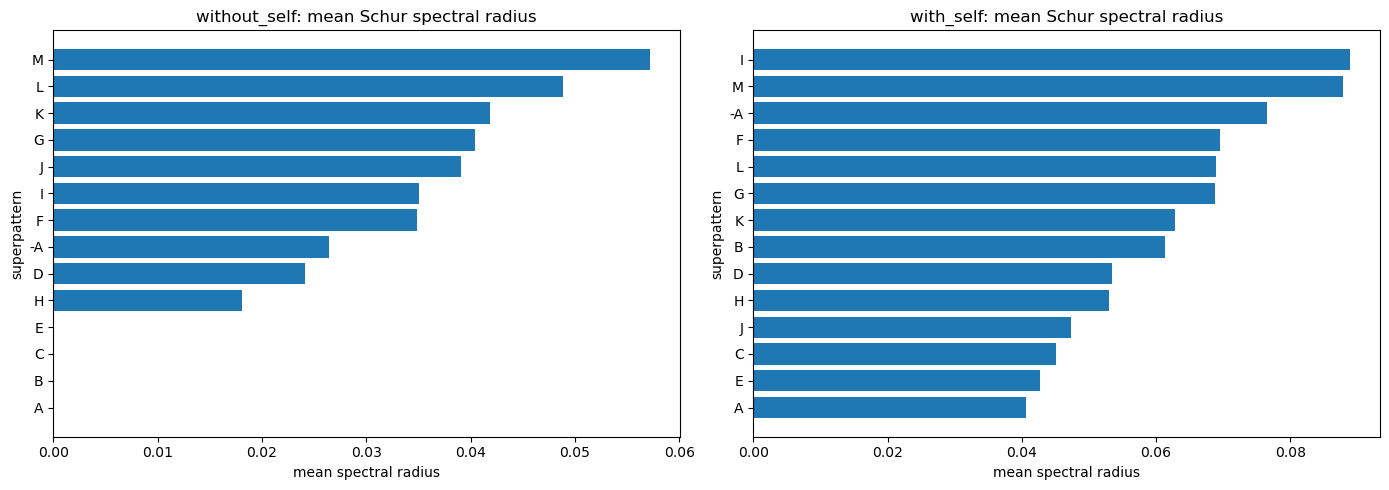

In [10]:
summary=pd.concat([analysis.summarize_by_superpattern(schur_no),analysis.summarize_by_superpattern(schur_self)],ignore_index=True)
display(summary)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for scenario,ax in zip(["without_self","with_self"],axes):
    plot=summary[summary.scenario==scenario].sort_values("mean_spectral_radius")
    ax.barh(plot.superpattern,plot.mean_spectral_radius)
    ax.set(title=f"{scenario}: mean Schur spectral radius",xlabel="mean spectral radius",ylabel="superpattern")
fig.tight_layout(); plt.show()

## Self-weight sensitivity

This paired comparison aligns the same motif occurrence under no-self and with-self assumptions. Large changes identify motif subnetworks where diagonal self-weights materially change the local Schur spectrum or the degree of non-normal coupling.

,motif_acronym_without_self,superpattern,spectral_radius_without_self,spectral_radius_with_self,spectral_radius_change_from_self,schur_offdiag_norm_without_self,schur_offdiag_norm_with_self,schur_offdiag_change_from_self
0,EC-LI/II-MP | EC-LIII-PSt | EC-LIV/VI-DeeMPr,A,0.0,0.663075,0.663075,1.194767,0.676295,-0.518473
1,CA1-RadTriLam | EC-LI/II-MP | EC-LIII-PSt,B,0.0,0.663075,0.663075,1.232930,0.697896,-0.535034
2,CA1-Bas | EC-LI/II-MP | EC-LIII-P,B,0.0,0.663075,0.663075,1.541598,0.872617,-0.668981
3,EC-LI/II-MP | EC-LIII-PSt | MEC-LV-MP,A,0.0,0.663075,0.663075,1.193016,0.675303,-0.517713
4,EC-LI/II-MP | EC-LIII-PSt | LEC-LVI-MP,A,0.0,0.663075,0.663075,1.193044,0.675319,-0.517725
5,EC-LI/II-MP | MEC-LII-OblP | EC-LV-DeeP,C,0.0,0.663075,0.663075,1.041628,0.589610,-0.452017
6,CA1-RadG | EC-LI/II-MP | EC-LIII-PSt,B,0.0,0.663075,0.663075,1.193121,0.675363,-0.517758
7,CA1-SUBProP | EC-LI/II-MP | EC-LIII-PSt,B,0.0,0.663075,0.663075,1.193272,0.675448,-0.517824
8,CA1-RadTriLam | EC-LI/II-MP | EC-LIII-P,B,0.0,0.663075,0.663075,1.540877,0.872209,-0.668668
9,CA1-OriAlv | EC-LI/II-MP | EC-LIII-PSt,B,0.0,0.663075,0.663075,1.570515,0.888986,-0.681530


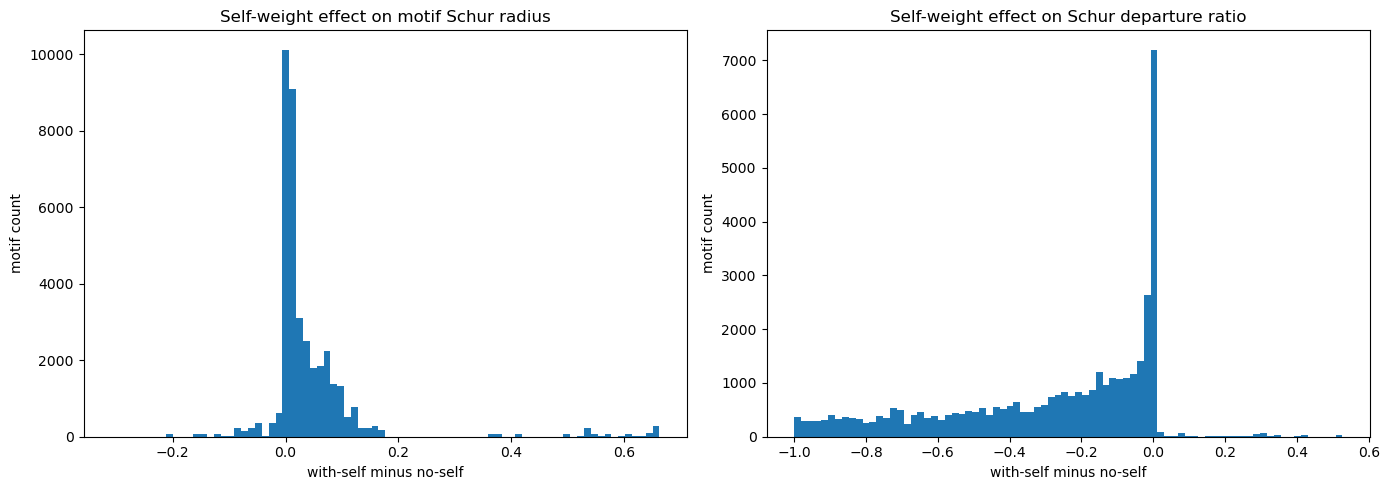

In [11]:
comparison=analysis.compare_self_scenarios(schur_no,schur_self)
display(comparison.head(25)[["motif_acronym_without_self","superpattern","spectral_radius_without_self","spectral_radius_with_self","spectral_radius_change_from_self","schur_offdiag_norm_without_self","schur_offdiag_norm_with_self","schur_offdiag_change_from_self"]])
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(comparison.spectral_radius_change_from_self,bins=80)
axes[0].set(title="Self-weight effect on motif Schur radius",xlabel="with-self minus no-self",ylabel="motif count")
axes[1].hist(comparison.departure_ratio_change_from_self,bins=80)
axes[1].set(title="Self-weight effect on Schur departure ratio",xlabel="with-self minus no-self",ylabel="motif count")
fig.tight_layout(); plt.show()


## Cell-type pathways emphasized by Schur modes

This section asks which cell types repeatedly appear in the strongest motif Schur modes. Repeated dominant Schur-node appearances suggest candidate local pathway junctions, especially when those same cells were also highlighted by Green's influence or pathway consensus analyses.

In [12]:
cells_no=analysis.summarize_cells(schur_no,top_n=500)
cells_self=analysis.summarize_cells(schur_self,top_n=500)
cells_no.insert(1,"cell_type_acronym",cells_no.cell_type.map(acronym_map).fillna(cells_no.cell_type))
cells_self.insert(1,"cell_type_acronym",cells_self.cell_type.map(acronym_map).fillna(cells_self.cell_type))
print("Top cells without self-weights"); display(cells_no.head(25))
print("Top cells with self-weights"); display(cells_self.head(25))


Top cells without self-weights


,cell_type,cell_type_acronym,top_motif_mentions,dominant_schur_mentions
0,EC LI II Multipolar Pyramidal,EC-LI/II-MP,248,162
1,DG Granule,DG-Gr,169,156
2,EC LI II Pyramidal Fan,EC-LI/II-PFan,83,79
3,CA3c Pyramidal,CA3c-P,90,70
4,CA2 Pyramidal,CA2-P,88,13
5,DG AIPRIM,DG-AIPRIM,87,7
6,CA3 Pyramidal,CA3-P,12,5
7,MEC LII Stellate,MEC-LII-St,86,2
8,CA1 Back Projection,CA1-BackProj,13,1
9,CA1 Pyramidal,CA1-P,8,1


Top cells with self-weights


,cell_type,cell_type_acronym,top_motif_mentions,dominant_schur_mentions
0,EC LI II Multipolar Pyramidal,EC-LI/II-MP,500,362
1,EC LII III Pyramidal Tripolar,EC-LII/III-PT,83,64
2,MEC LII Stellate,MEC-LII-St,83,62
3,MEC LIII Bipolar Complex Pyramidal,MEC-LIII-BipCxP,27,12
4,EC LI II Pyramidal Fan,EC-LI/II-PFan,83,0
5,MEC LIII Complex Pyramidal,MEC-LIII-CxP,82,0
6,LEC LIII Complex Pyramidal,LEC-LIII-CxP,81,0
7,LEC LIII Multipolar Principal,LEC-LIII-MPr,81,0
8,MEC LII III Pyramidal Multiform,MEC-LII/III-PMul,8,0
9,MEC LV Pyramidal,MEC-LV-P,8,0


## Exported results

The exported tables preserve the occurrence-level Schur modes, superpattern summaries, self-weight sensitivity table, and top-cell rankings for downstream pathway interpretation or follow-up decomposition.

In [13]:
exported=analysis.export_results(OUTPUT_DIR,schur_no,schur_self,summary,comparison,cells_no,cells_self)
acronyms.to_csv(OUTPUT_DIR/"cell_type_acronym_map.csv",index=False)
ranked_modes_no.to_csv(OUTPUT_DIR/"ranked_schur_modes_without_self.csv",index=False)
ranked_modes_self.to_csv(OUTPUT_DIR/"ranked_schur_modes_with_self.csv",index=False)
perturb_no.to_csv(OUTPUT_DIR/"motif_enhancement_ablation_without_self.csv",index=False)
perturb_self.to_csv(OUTPUT_DIR/"motif_enhancement_ablation_with_self.csv",index=False)
motif_index_no["matrix"].to_csv(OUTPUT_DIR/"motif_index_matrix_without_self.csv")
motif_index_self["matrix"].to_csv(OUTPUT_DIR/"motif_index_matrix_with_self.csv")
motif_index_no["modes"].to_csv(OUTPUT_DIR/"motif_index_modes_without_self.csv",index=False)
motif_index_self["modes"].to_csv(OUTPUT_DIR/"motif_index_modes_with_self.csv",index=False)
motif_index_no["motif_participation"].to_csv(OUTPUT_DIR/"motif_index_participation_without_self.csv",index=False)
motif_index_self["motif_participation"].to_csv(OUTPUT_DIR/"motif_index_participation_with_self.csv",index=False)
motif_index_no["cell_loadings"].to_csv(OUTPUT_DIR/"motif_index_cell_loadings_without_self.csv",index=False)
motif_index_self["cell_loadings"].to_csv(OUTPUT_DIR/"motif_index_cell_loadings_with_self.csv",index=False)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.resolve())





/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/cell_type_acronym_map.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_enhancement_ablation_with_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_enhancement_ablation_without_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_index_cell_loadings_with_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_index_cell_loadings_without_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_index_matrix_with_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_index_matrix_without_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_schur_decomposition_analysis/motif_index_modes_with_self.csv
/Users/raniceto/Documents/Hippocampome/outputs/mo

## Interpretation guide

A motif with a larger Schur spectral radius has a stronger local recurrent or directional mode after the global spectral-radius scaling already applied upstream. A motif with a larger Schur off-diagonal norm or departure ratio is more non-normal: its local pathways can transiently pass activity through the 3-node block even when eigenvalues alone look modest. Self-weight sensitivity should be interpreted as diagonal terms changing the local mode geometry, not as proof that the motif edges alone caused a global circuit effect.